In [ ]:
import time
import random
import csv
import sys
import gc
import statistics

import matplotlib.pyplot as plt
from IPython.display import Image, display

# Iterative Binary Search
 <br>

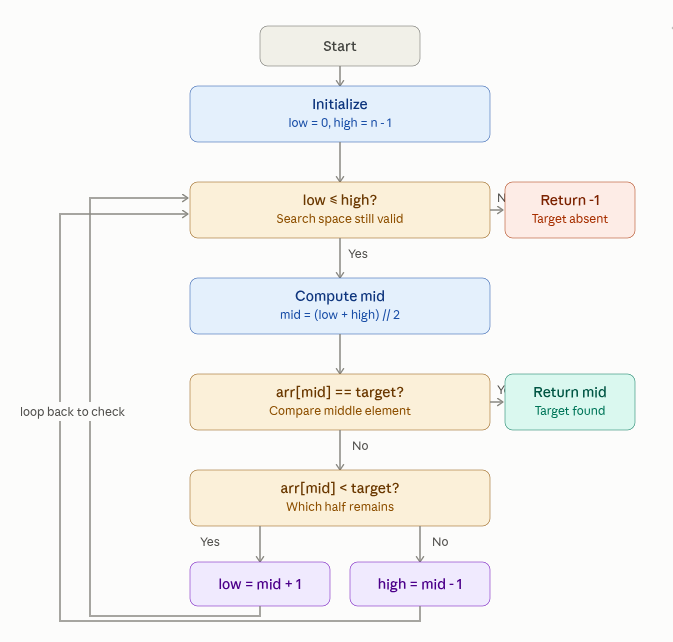

# Recursive Binary Search

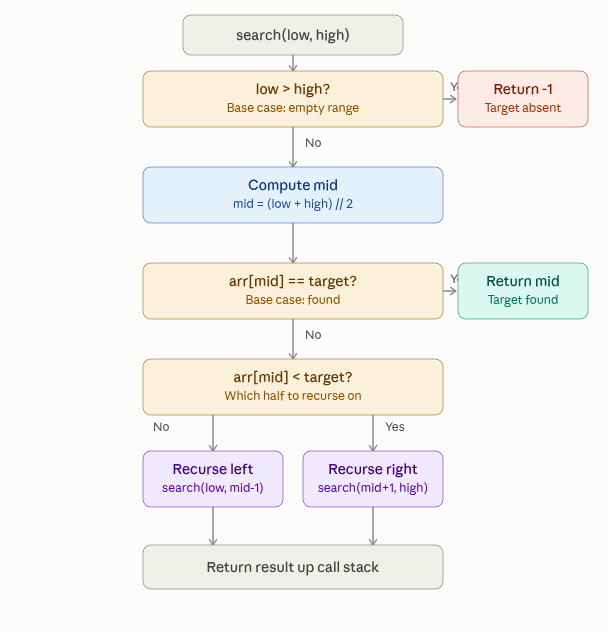

In [ ]:


def binary_search_iterative(arr, target):
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1


def binary_search_recursive(arr, target, low, high):
    if low > high:
        return -1
    mid = (low + high) // 2
    if arr[mid] == target:
        return mid
    elif arr[mid] < target:
        return binary_search_recursive(arr, target, mid + 1, high)
    else:
        return binary_search_recursive(arr, target, low, mid - 1)



In [ ]:

# ---------------------------------------------------------
# 3. Timing helper
#    Runs the search several times and returns AVERAGE time
#    (single run is too noisy / too fast for small n)
# ---------------------------------------------------------
def measure_time(func, arr, target, is_recursive=False, trials=200):  # 50 -> 200 trials
    if is_recursive:
        func(arr, target, 0, len(arr) - 1)
    else:
        func(arr, target)

    times = []
    gc_was_enabled = gc.isenabled()
    gc.disable()
    try:
        for _ in range(trials):
            start = time.perf_counter()
            if is_recursive:
                func(arr, target, 0, len(arr) - 1)
            else:
                func(arr, target)
            end = time.perf_counter()
            times.append(end - start)
    finally:
        if gc_was_enabled:
            gc.enable()

   return sum(times) / len(times)


In [ ]:

# ---------------------------------------------------------
# 4. Experiment: run for increasing input sizes
# ---------------------------------------------------------
def run_experiment():
    # increase recursion limit for large n (recursive version needs it)
    sys.setrecursionlimit(10000)

    input_sizes = [100, 500, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]
    results = []  # each row: size, iter_time, rec_time

    for n in input_sizes:
        arr = list(range(n))          # sorted array [0, 1, 2, ..., n-1]
        target = random.choice(arr)   # a random existing element (average case)

        iter_time = measure_time(binary_search_iterative, arr, target,
                                  is_recursive=False)
        rec_time = measure_time(binary_search_recursive, arr, target,
                                 is_recursive=True)

        results.append((n, iter_time, rec_time))
        print(f"n = {n:>8}  |  iterative = {iter_time*1e6:.3f} us  |  "
              f"recursive = {rec_time*1e6:.3f} us")

    return results


# ---------------------------------------------------------
# 5. Store results in a CSV file
# ---------------------------------------------------------
def save_results_csv(results, filename="results.csv"):
    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["input_size", "iterative_time_sec", "recursive_time_sec"])
        writer.writerows(results)
    print(f"\nResults saved to {filename}")



n =      100  |  iterative = 0.821 us  |  recursive = 0.889 us
n =      500  |  iterative = 1.103 us  |  recursive = 1.393 us
n =     1000  |  iterative = 1.455 us  |  recursive = 1.772 us
n =     5000  |  iterative = 1.513 us  |  recursive = 1.812 us
n =    10000  |  iterative = 1.889 us  |  recursive = 2.340 us
n =    50000  |  iterative = 2.318 us  |  recursive = 2.852 us
n =   100000  |  iterative = 2.464 us  |  recursive = 3.042 us
n =   500000  |  iterative = 2.494 us  |  recursive = 3.056 us
n =  1000000  |  iterative = 2.608 us  |  recursive = 3.269 us

Results saved to results.csv
Graph saved to performance_graph.png


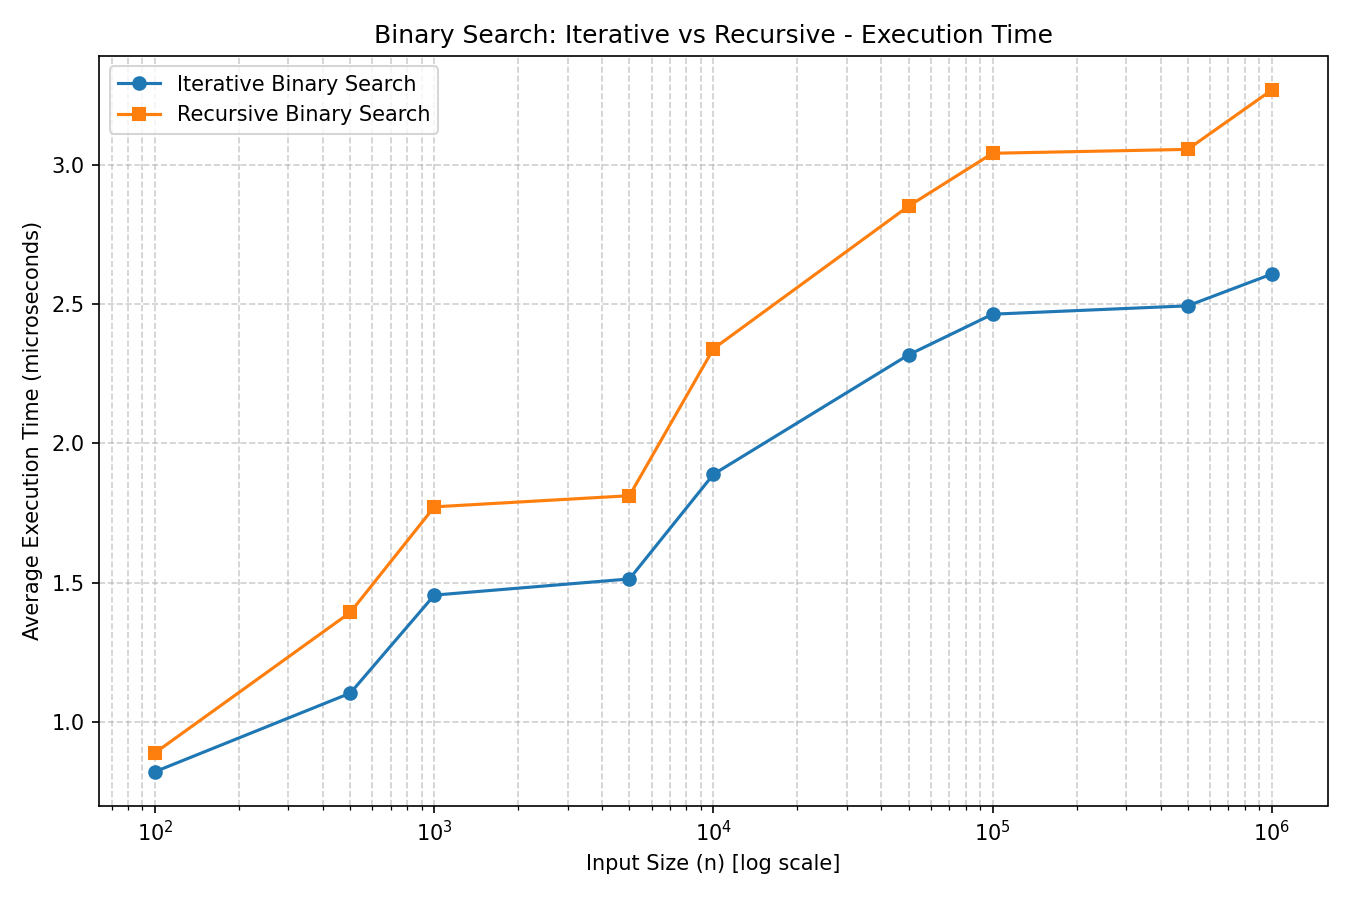

In [ ]:
# ---------------------------------------------------------
# 6. Plot performance graph
# ---------------------------------------------------------
def plot_results(results, filename="performance_graph.png"):
    sizes = [r[0] for r in results]
    iter_times = [r[1] * 1e6 for r in results]   # convert to microseconds
    rec_times = [r[2] * 1e6 for r in results]

    plt.figure(figsize=(9, 6))
    plt.plot(sizes, iter_times, marker="o", label="Iterative Binary Search")
    plt.plot(sizes, rec_times, marker="s", label="Recursive Binary Search")
    plt.xscale("log")  # input sizes span orders of magnitude
    plt.xlabel("Input Size (n) [log scale]")
    plt.ylabel("Average Execution Time (microseconds)")
    plt.title("Binary Search: Iterative vs Recursive - Execution Time")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(filename, dpi=150)
    plt.close() # Close the plot to free memory
    print(f"Graph saved to {filename}")
    return filename


# ---------------------------------------------------------
# main
# ---------------------------------------------------------
if __name__ == "__main__":
    results = run_experiment()
    save_results_csv(results)
    plot_filename = plot_results(results)
    display(Image(plot_filename)) # Explicitly display the saved image